# Employee Turnover Prediction
Predicting and reducing employee attrition using machine learning and behavioral clustering.

## Project Overview

Employee attrition is one of the most costly challenges in workforce management. This project builds a machine learning pipeline to predict which employees are most likely to leave, using the IBM HR Analytics dataset from Kaggle.

The approach covers the full analysis lifecycle:

- **Exploratory Data Analysis** — identifying key drivers of attrition through correlation analysis and feature distributions
- **Behavioral Clustering** — segmenting employees who left into distinct groups using K-Means
- **Feature Engineering** — encoding, scaling, and class balancing with SMOTE
- **Model Training** — comparing Logistic Regression, Random Forest, and Gradient Boosting
- **API Layer** — FastAPI endpoint for real-time attrition prediction

## Setup

In [1]:
# Data handling
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
from sklearn.cluster import KMeans

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use("seaborn-v0_8")

## Data Loading & Inspection

In [2]:
# Creating Folder Path And Loading Data
data_path = Path('../data/ibm_hr_attrition.csv')

raw_data = pd.read_csv(data_path, encoding='UTF-8')
df = raw_data.copy()



In [3]:
# Quick Inspection
display(df.head())
print('\nShape:', df.shape)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Shape: (1470, 35)


In [4]:
# Information About The Data
df.info()

# Summary Statistics
display(df.describe(include='all'))

for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) < 20:  
        print(f"\nColumn: {col}")
        print(unique_vals)




<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000



Column: Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: BusinessTravel
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Column: Department
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

Column: Education
[2 1 4 3 5]

Column: EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Column: EmployeeCount
[1]

Column: EnvironmentSatisfaction
[2 3 4 1]

Column: Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Column: JobInvolvement
[3 2 4 1]

Column: JobLevel
[2 1 3 4 5]

Column: JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Reso

## Data Quality & Cleaning

In [5]:
# Checking For Missing Values And Duplicate Rows
print('\nNumber Of Missing Values:', df.isnull().sum().sum())
print('Number Of Duplicate Rows:', df.duplicated().sum())

print('Initial Shape:', df.shape)


COLS_TO_DROP = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=COLS_TO_DROP)
print('Shape After Dropping Unnecessary Columns:', df.shape)



Number Of Missing Values: 0
Number Of Duplicate Rows: 0
Initial Shape: (1470, 35)
Shape After Dropping Unnecessary Columns: (1470, 31)


## Exploratory Data Analysis

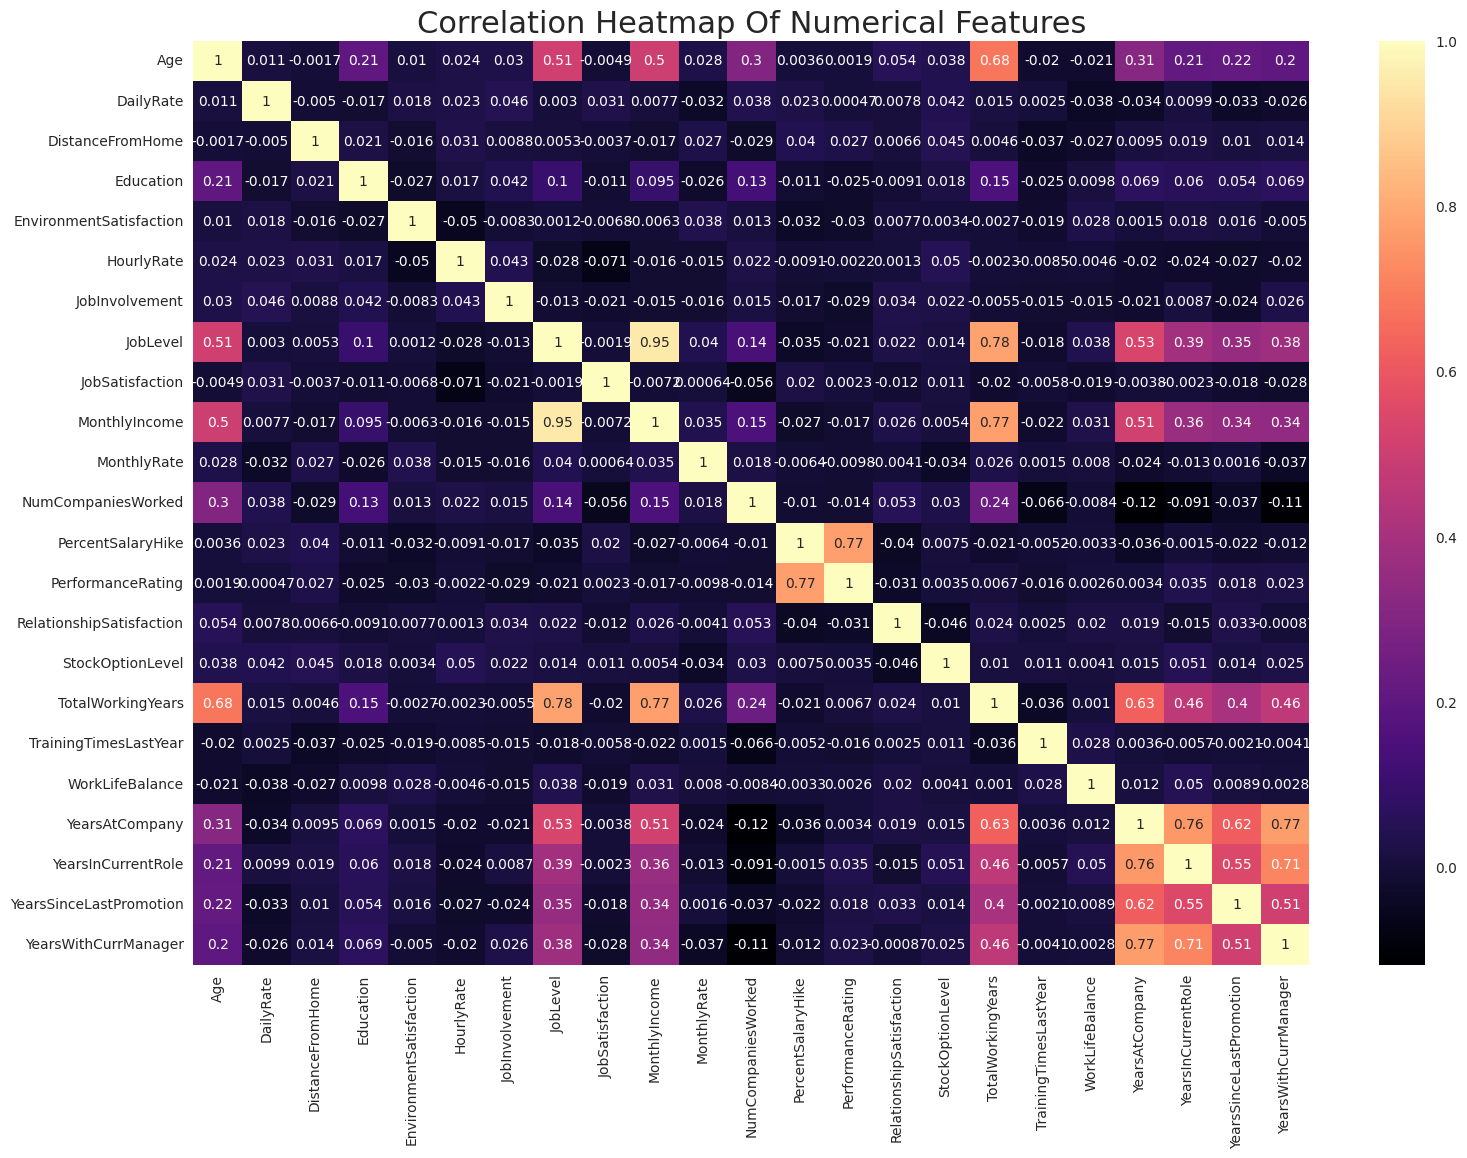

In [6]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18, 12))
sns.heatmap(numeric_df.corr(), annot=True, cmap="magma")
plt.title("Correlation Heatmap Of Numerical Features", fontsize=22)
plt.savefig('../notebooks/figures/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis

The heatmap shows how strongly features are related to each other. The biggest standout is JobLevel and MonthlyIncome at 0.95. TotalWorkingYears, Age, and MonthlyIncome are all tied together too. Which makes sense, the longer you've worked, the older you are and the more you make.

The four "Years" columns: YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager are all highly correlated with each other, so they're telling a similar story about how long someone has been around. 

On the flip side, DailyRate, HourlyRate, and MonthlyRate have almost no correlation with anything, so they probably won't help the model much.

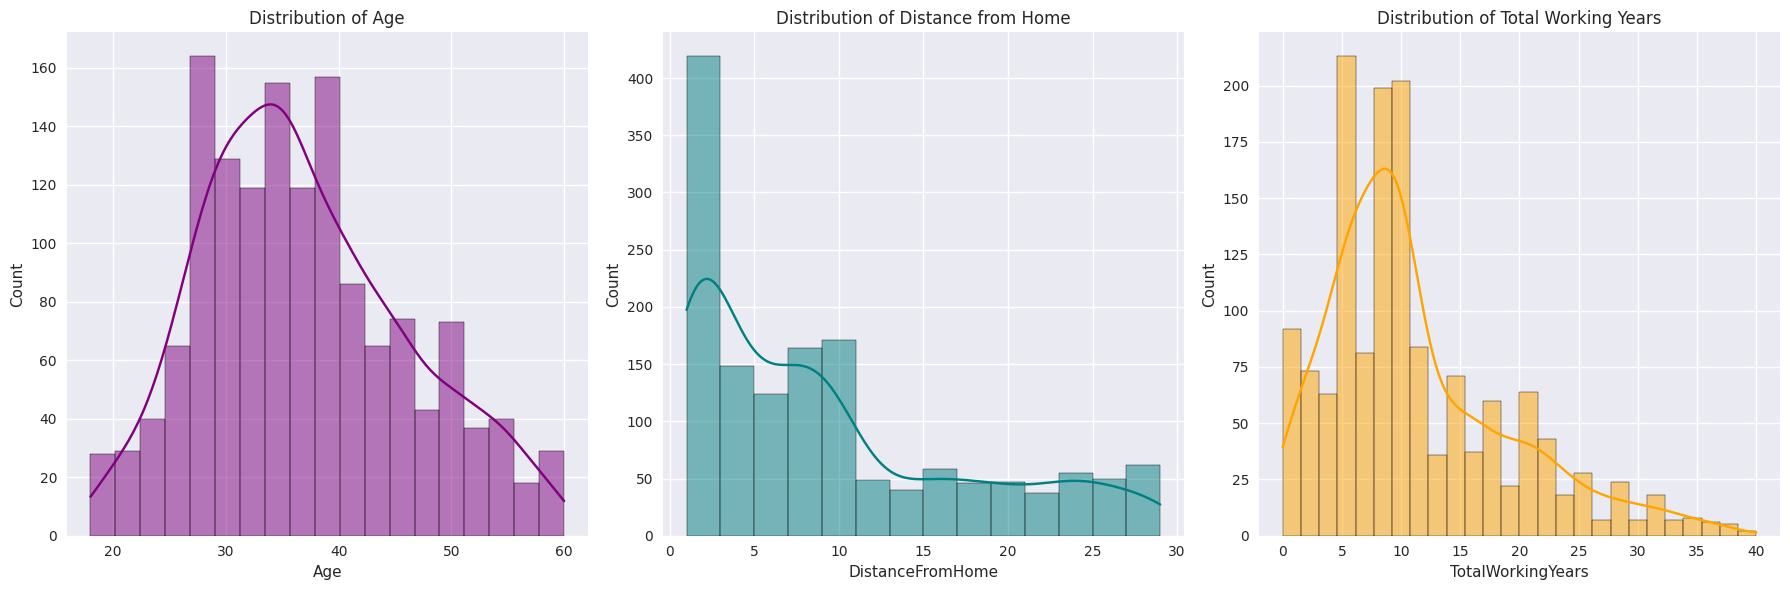

In [7]:
# Histogram of Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='purple')
axes[0].set_title("Distribution of Age")

sns.histplot(df['DistanceFromHome'], kde=True, ax=axes[1], color='teal')
axes[1].set_title("Distribution of Distance from Home")

sns.histplot(df['TotalWorkingYears'], kde=True, ax=axes[2], color='orange')
axes[2].set_title("Distribution of Total Working Years")

plt.tight_layout()
plt.savefig('../notebooks/figures/hist_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Feature Distributions

Age follows a roughly normal distribution centered around the mid-30s, with a slight right skew. Most employees are in the 28–42 range, and attrition tends to be higher among younger employees early in their careers.

Distance From Home is heavily right-skewed, but it doesn't seem to affect attrition all that much. The heatmap also confirms there's no correlation with the other criteria or features. 

Total Working Years is similarly right-skewed. The majority of employees have fewer than 15 years of experience, while a smaller cohort has 20–40 years. Employees earlier in their careers show higher attrition rates, making this a meaningful predictor.

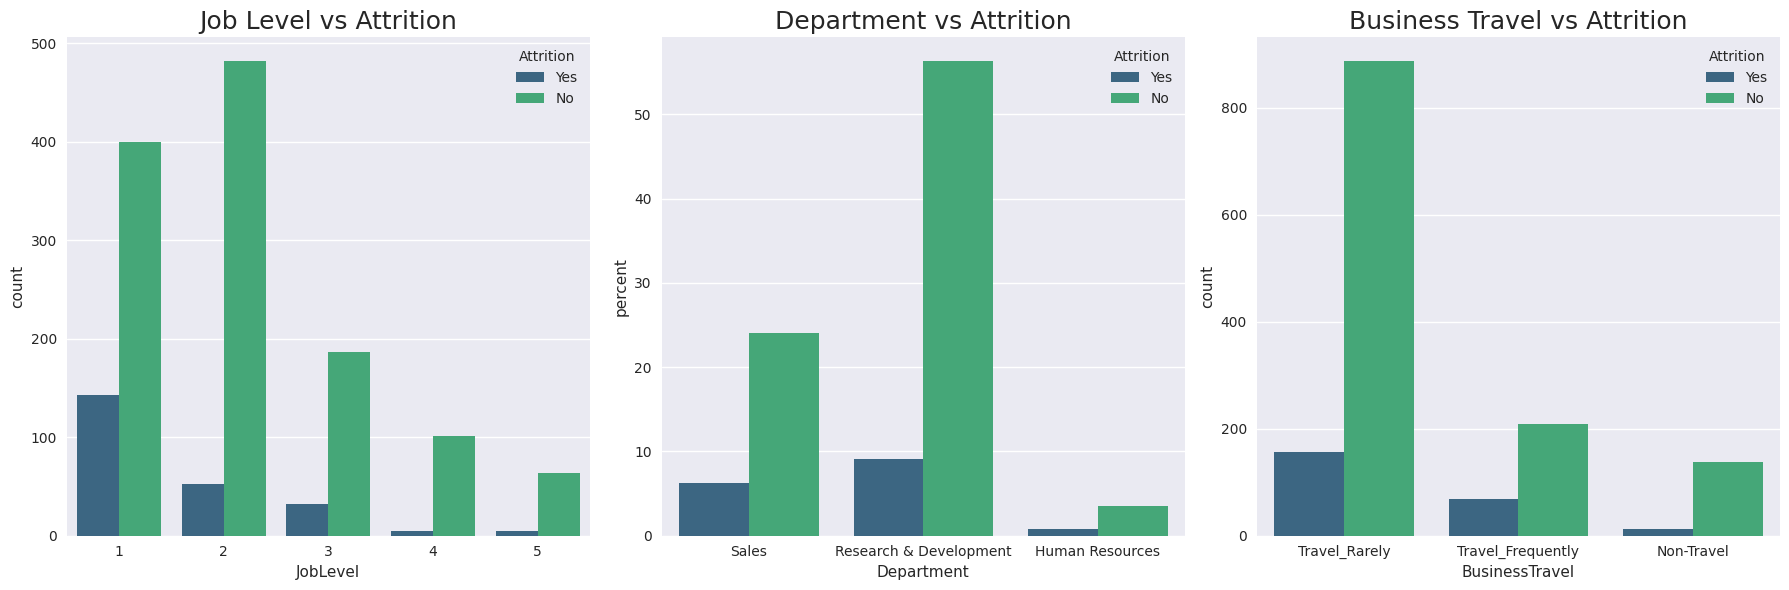

In [8]:
# Count Plots For Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


sns.countplot(data=df, x='JobLevel', hue='Attrition', ax=axes[0], palette='viridis')
axes[0].set_title('Job Level vs Attrition', fontsize=18)

sns.countplot(data=df, x='Department', hue='Attrition', stat='percent', ax=axes[1], palette='viridis')
axes[1].set_title('Department vs Attrition', fontsize=18)

sns.countplot(data=df, x='BusinessTravel', hue='Attrition',  ax=axes[2], palette='viridis')
axes[2].set_title('Business Travel vs Attrition', fontsize=18)


plt.tight_layout()
plt.savefig('../notebooks/figures/countplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Job Level, Department, Business Travel  vs. Attrition

Attrition follows right skew with respect to Job Level. Employees with lower job level show disproportionately higher turnover. This suggests younger and/or less-tenured employees who earn less tend to leave. 

Department shows that Sales has a higher ratio of attrition than other deprtments.  

The final subplot, Business Travel, follows a right skew on counts. But employees that travel frequently have a higher ratio of attrition than the other two categories. 

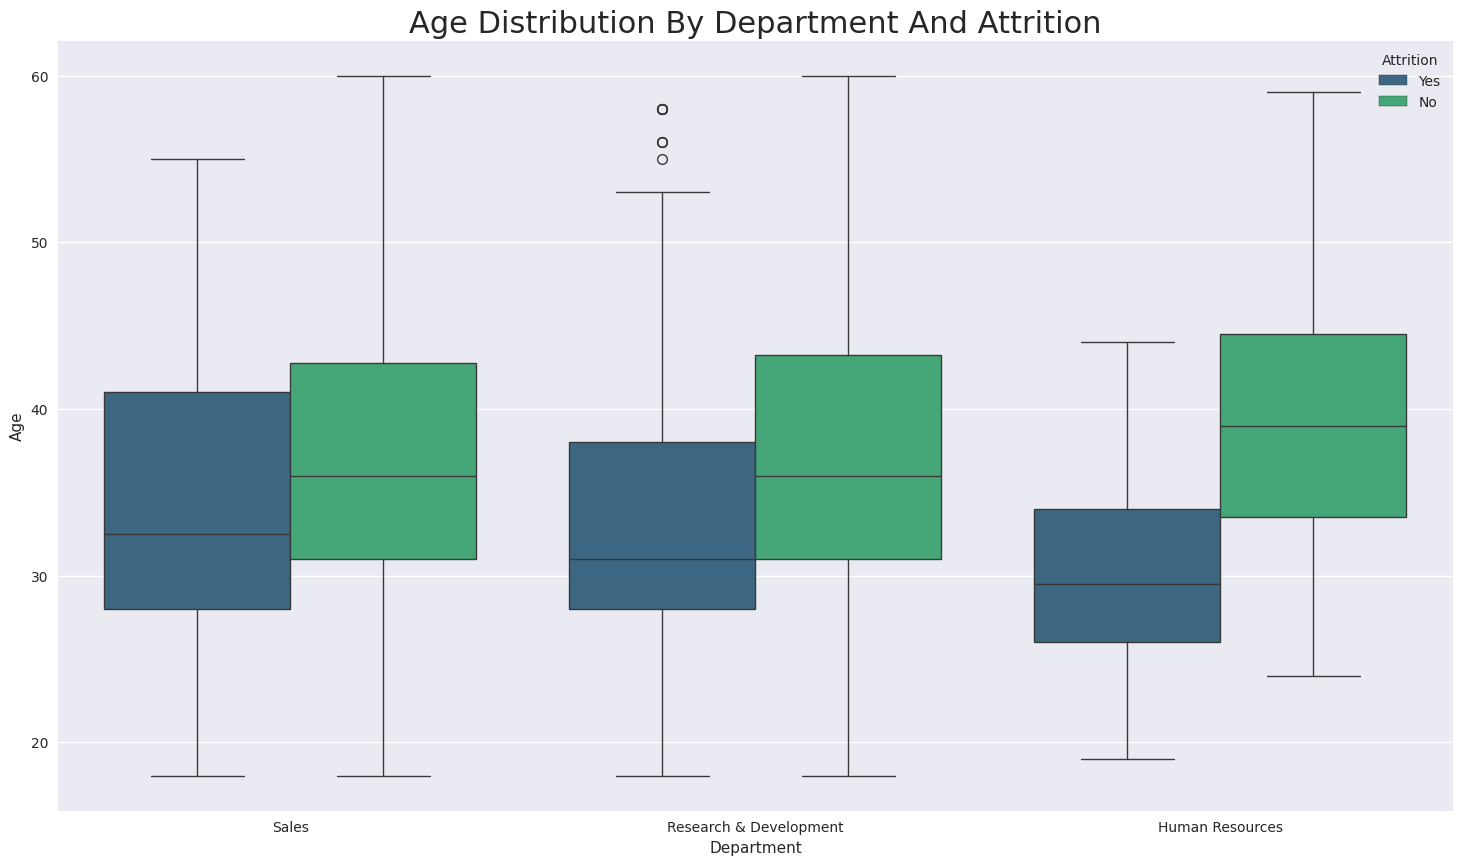

In [9]:
# Box Plots For Numerical Features By Attrition
plt.figure(figsize=(18, 10))
sns.boxplot(data=df, x='Department', y='Age', hue='Attrition', palette='viridis')

plt.title('Age Distribution By Department And Attrition', fontsize=22)
plt.savefig('../notebooks/figures/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Age & Department vs Attrition Boxplots

Youth is a company-wide attrition risk, but it hits HR hardest proportionally and Sales most broadly. Combined with earlier findings, the highest risk profile is now: young, entry-level, Sales or HR, frequent traveler, low income.

## Behavioral Clustering

Before building predictive models, K-Means clustering is applied to employees who left to identify distinct behavioral segments. This unsupervised step reveals why people leave, not just that they leave. This can enable targeted retention strategies per segment.

In [10]:
# Filtering Employees Who Left
left_df = df[df['Attrition'] == 'Yes'][['MonthlyIncome', 'YearsSinceLastPromotion']].copy()

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
left_df['cluster'] = kmeans.fit_predict(left_df)

left_df.head(5)

,MonthlyIncome,YearsSinceLastPromotion,cluster
0,5993,0,0
2,2090,0,2
14,2028,0,2
21,3407,0,2
24,2960,1,2


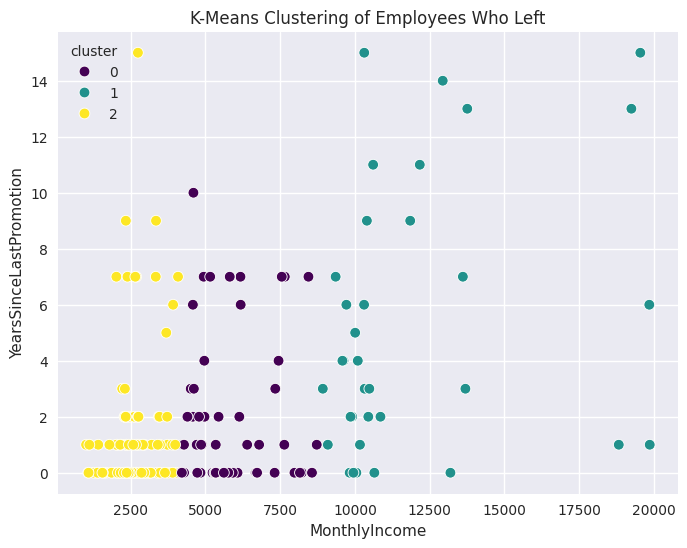

In [11]:
# Visualizing The Clusters On A Plot

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=left_df,
    x='MonthlyIncome',
    y='YearsSinceLastPromotion',
    hue='cluster',
    palette='viridis',
    s=60
)
plt.title("K-Means Clustering of Employees Who Left")
plt.savefig('../notebooks/figures/k_means_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

### Cluster Interpretation

Three distinct attrition profiles are represented here: Cluster 0 (purple), cluster 1 (teal), and cluster 2 (yellow). The three reasons why these employees left was bad pay, career stagnation, and income floor too low to stay regardless of promotion. 

The purple and yellow clusters (clusters 0, 2 respectively) are lower income earners on the bottom left. Regardless of recent promotions they left for better pay.

The teal cluster (cluster 1) are the highest income earners and those with higher seniority. Some left despite recent promotions but other clusters show higher earners leaving after 9 years or more since their last promotion. Monthly income was probably not the factor for attrition but stagnation or lack of growth in their career.